In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks import DDM

### Metas

In [3]:
intrinsic_params = ["v", "a", "tau", "s_v", "s_tau", "decay"]
num_obs = 2000
num_configs = 6
num_regressors = 4
p_free = 0.5

### Priors

In [4]:
# Priors: intercept vs slope samplers per intrinsic
priors = {
    "v":     {"intercept": lambda: np.random.gamma(3.0, 0.8),
              "slope":     lambda: np.random.normal(0.0, 3.0)},
    "a":     {"intercept": lambda: np.random.gamma(10.0, 0.3),
              "slope":     lambda: np.random.normal(0.0, 1.0)},
    "tau":   {"intercept": lambda: np.random.gamma(3.0, 0.2),
              "slope":     lambda: 0.0},
    "s_v":   {"intercept": lambda: np.random.gamma(1.0, 0.2),
              "slope":     lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.uniform(0.0, 0.4),
              "slope":     lambda: 0.0},
    "decay": {"intercept": lambda: np.random.gamma(1.0, 0.4),
              "slope":     lambda: 0.0},
}

### Context Manager

In [5]:
cm = ContextManager()  # not used in full-regression path

family = NestedModelFamily(
    name="DDM",
    model=DDM(),
    context_manager=cm,
    prior_fun=priors,
    intrinsic_params=intrinsic_params,
)

In [6]:
out = family.sample(
    design_config=None,
    num_obs=num_obs,
    num_regressors=num_regressors,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a"},
        intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},  # different mask each run, reproducible
    )
)

TypeError: DDM.simulate() got an unexpected keyword argument 'num_obs'

In [373]:
out

{'model_name': 'DDM',
 'design_config': {'1': ['v', 'a', 'tau', 's_v', 's_tau', 'decay'],
  'u_1': ['a'],
  'u_2': ['v'],
  'u_3': ['v']},
 'design_matrix': array([[1.        , 0.69646406, 0.26534805, 0.        ],
        [1.        , 0.88504857, 0.40329117, 0.        ],
        [1.        , 0.21540329, 0.12688804, 1.        ],
        ...,
        [1.        , 0.78758353, 0.41970548, 1.        ],
        [1.        , 0.42989966, 0.06344024, 0.        ],
        [1.        , 0.82243496, 0.5310086 , 1.        ]],
       shape=(2000, 4), dtype=float32),
 'parameter_mask': array([[1., 1., 1., 1., 1., 1.],
        [0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.]], dtype=float32),
 'parameter_matrix': array([[ 2.7587986 ,  3.385262  ,  0.66910225,  0.9275362 ,  0.3069727 ,
          1.4794292 ],
        [ 0.        ,  0.22642556,  0.        ,  0.        ,  0.        ,
          0.        ],
        [-2.0368364 ,  0.        ,  0.        ,  0.      

In [374]:
design_matrix     = out["design_matrix"]
parameter_mask    = out["parameter_mask"]
parameter_matrix  = out["parameter_matrix"]
params_for_model  = out["params_samples"]
sim_data          = out["sim_data"]

In [375]:
design_matrix

array([[1.        , 0.69646406, 0.26534805, 0.        ],
       [1.        , 0.88504857, 0.40329117, 0.        ],
       [1.        , 0.21540329, 0.12688804, 1.        ],
       ...,
       [1.        , 0.78758353, 0.41970548, 1.        ],
       [1.        , 0.42989966, 0.06344024, 0.        ],
       [1.        , 0.82243496, 0.5310086 , 1.        ]],
      shape=(2000, 4), dtype=float32)

In [376]:
parameter_mask

array([[1., 1., 1., 1., 1., 1.],
       [0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.]], dtype=float32)

In [377]:
parameter_matrix

array([[ 2.7587986 ,  3.385262  ,  0.66910225,  0.9275362 ,  0.3069727 ,
         1.4794292 ],
       [ 0.        ,  0.22642556,  0.        ,  0.        ,  0.        ,
         0.        ],
       [-2.0368364 ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 3.688956  ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ]], dtype=float32)

In [378]:
sim_data

{'rts': array([0.5422313 , 0.5554971 , 0.53720355, ..., 0.5685479 , 0.806655  ,
        0.7398856 ], shape=(2000,), dtype=float32),
 'choices': array([1., 1., 1., ..., 1., 1., 1.], shape=(2000,), dtype=float32)}

In [379]:
print("design_matrix shape        :", design_matrix.shape)        # (N, K)
print("parameter_mask shape       :", parameter_mask.shape)       # (K, M)
print("parameter_matrix shape     :", parameter_matrix.shape)     # (K, M)

design_matrix shape        : (2000, 4)
parameter_mask shape       : (4, 6)
parameter_matrix shape     : (4, 6)


In [380]:
design_matrix

array([[1.        , 0.69646406, 0.26534805, 0.        ],
       [1.        , 0.88504857, 0.40329117, 0.        ],
       [1.        , 0.21540329, 0.12688804, 1.        ],
       ...,
       [1.        , 0.78758353, 0.41970548, 1.        ],
       [1.        , 0.42989966, 0.06344024, 0.        ],
       [1.        , 0.82243496, 0.5310086 , 1.        ]],
      shape=(2000, 4), dtype=float32)

In [381]:
intrinsic_values_matrix = (design_matrix @ parameter_matrix).astype(np.float32)
assert intrinsic_values_matrix.shape == (num_samples, len(intrinsic_params))

In [382]:
col_idx = {name: j for j, name in enumerate(intrinsic_params)}
v_arr = params_for_model["v"]
a_arr = params_for_model["a"]
assert np.allclose(v_arr, intrinsic_values_matrix[:, col_idx["v"]])
assert np.allclose(a_arr, intrinsic_values_matrix[:, col_idx["a"]])

In [384]:
intercepts = out["params_samples"].get("_intercepts", {})
print("Intercepts:", {k: round(v, 4) for k, v in intercepts.items()})

Intercepts: {}


In [385]:
rts = sim_data["rts"]
choices = sim_data["choices"]
print("Simulated RTs:", np.nanmin(rts[rts>0]), "→", np.nanmax(rts))
print("Choice rate (mean):", np.mean(choices))

Simulated RTs: 0.51673764 → 0.8233802
Choice rate (mean): 1.0


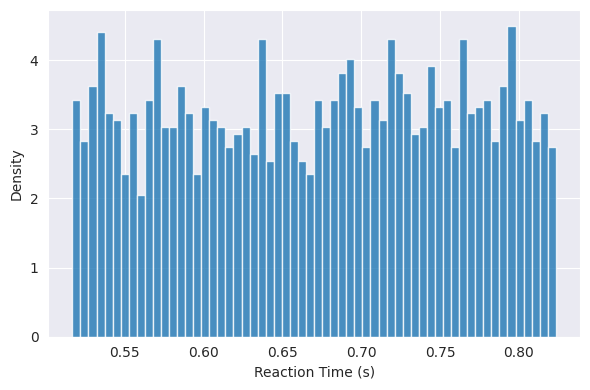

In [386]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(rts[rts > 0], bins=60, density=True, alpha=0.8)
ax.set_xlabel("Reaction Time (s)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

### Testing multiple batches

In [387]:
runs = []
for k in range(num_configs):
    res = family.sample(
        design_config=None,                 # AUTO: build_random_parameter_mask + mask_to_design_config
        priors=priors,
        num_samples=num_samples,
        num_design_factors=num_factors,
        mask_randomizer_kwargs=dict(
            mandatory_intrinsics={"v", "a"},
            intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},
        ),
    )
    runs.append(res)

In [388]:
def check_run(res):
    dm, pm = res["design_matrix"], res["parameter_matrix"]
    assert dm.shape == (num_samples, num_factors)
    assert pm.shape == (num_factors, len(intrinsic_params))
    rts = res["sim_data"]["rts"]; choices = res["sim_data"]["choices"]
    assert rts.shape == (num_samples,) and choices.shape == (num_samples,)
    assert np.isfinite(rts).all()  # if timeouts exist they’ll be -1.0; adjust if you want to allow them
    return rts

all_rts = [check_run(r) for r in runs]
print(f"OK: ran {len(runs)} configs × {num_samples} trials with AUTO full-regression.")

OK: ran 6 configs × 2000 trials with AUTO full-regression.


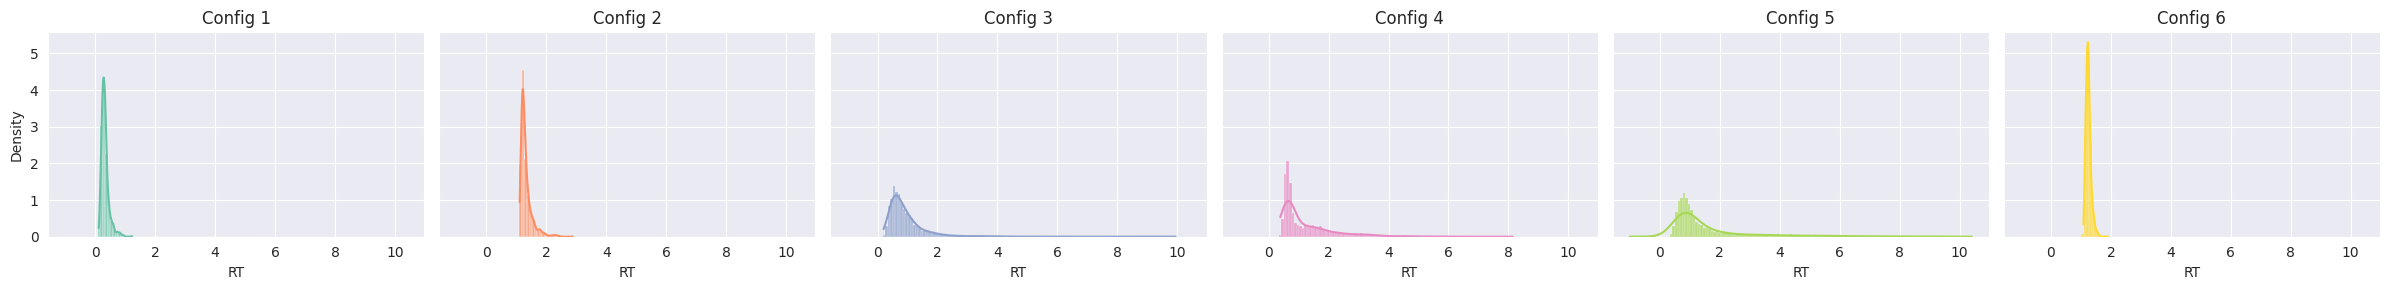

In [389]:
fig, axes = plt.subplots(1, num_configs, figsize=(4*num_configs, 3), sharex=True, sharey=True)
bins = np.linspace(0.0, 5.0, 60)
palette = sns.color_palette("Set2", n_colors=num_configs)

for ax, rts, idx in zip(np.atleast_1d(axes), all_rts, range(num_configs)):
    sns.histplot(rts, bins=bins, stat="density", kde=True, color=palette[idx], alpha=0.7, ax=ax)
    ax.set_title(f"Config {idx+1}")
    ax.set_xlabel("RT")
    ax.set_ylabel("Density")

plt.tight_layout()

### Batch sampling

In [396]:
samples = family.batch_sample(
    num_batches=2,
    num_samples=num_samples,
    num_design_factors=num_factors,
    priors=priors,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a"},
        intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},
    ),
)

In [397]:
samples

[{'model_name': 'DDM',
  'design_config': {'1': ['v', 'a', 'tau', 's_v', 's_tau', 'decay'],
   'u_1': [],
   'u_2': ['v'],
   'u_3': ['v'],
   'u_4': ['a'],
   'u_5': [],
   'u_6': ['a'],
   'u_7': [],
   'u_8': ['v']},
  'design_matrix': array([[1.        , 0.74434996, 0.10208017, ..., 0.18508196, 0.29768908,
          1.        ],
         [1.        , 0.64626473, 0.10181585, ..., 0.37230778, 0.48381838,
          1.        ],
         [1.        , 0.76681864, 0.38354388, ..., 0.46362695, 0.08644159,
          0.        ],
         ...,
         [1.        , 0.19968764, 0.298846  , ..., 0.89632607, 0.2610979 ,
          1.        ],
         [1.        , 0.9058195 , 0.5800173 , ..., 0.1918648 , 0.2535964 ,
          1.        ],
         [1.        , 0.17490125, 0.6795636 , ..., 0.61940265, 0.6070703 ,
          0.        ]], shape=(1149, 9), dtype=float32),
  'parameter_mask': array([[1., 1., 1., 1., 1., 1.],
         [0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0.],
    